# A newral network training from scratch for the XOR function

A small neural network example implemented manually, but using Autograd from torch. For the manual gradients calculation see the corresponding notebook in the tensorflow sister project.

## XOR Neural Network

A simple feed-forward network:
- 2 input neurons
- 2 hidden neurons
- 1 output neuron

Demonstrates:
- forward propagation
- backpropagation using Autograd
- binary classification

In [22]:
import torch
import matplotlib.pyplot as plt

First let us create the XOR inputs and expected outputs that we will be training our network on.

In [1]:
# 2 numbers input for XOR
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

# Expected values of XOR
y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])

print(X.dtype)  # torch.float32
print(y.dtype)  # torch.float32

torch.float32
torch.float32


In [15]:
def binary_cross_entropy(y, y_hat):
    eps = 1e-7
    y_hat = torch.clamp(y_hat, eps, 1 - eps)

    return -(y * torch.log(y_hat) +
             (1 - y) * torch.log(1 - y_hat)).mean()


tensor(1.1921e-07)

In [8]:
# note that this function is element-wise when applied to a vector or matrix
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

In [25]:
# initialize random weights and biases
W1 = torch.randn(2, 2, requires_grad=True)
b1 = torch.randn(2, requires_grad=True)

W2 = torch.randn(2, 1, requires_grad=True)
b2 = torch.randn(1, requires_grad=True)

lr = 0.1 # learning rate
epochs = 40_000


# training on the entire X at each epoch (batch gradient decent)
loss_history = []
for epoch in range(epochs):
    hidden = X @ W1 + b1  # torch.Size([4, 2])
    after_activation = sigmoid(hidden) # sigmoid is element-wise, so torch.Size([4, 2])
    output = sigmoid(after_activation @ W2 + b2) # torch.Size([4, 1]), so we can calculate loss on the y

    loss = binary_cross_entropy(y, output)

    loss.backward()

    with torch.no_grad():
        W1 -= lr * W1.grad
        b1 -= lr * b1.grad
        W2 -= lr * W2.grad
        b2 -= lr * b2.grad

    W1.grad.zero_()
    b1.grad.zero_()
    W2.grad.zero_()
    b2.grad.zero_()

    if (epoch)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, loss.item()))
        loss_history.append(loss.item())

Epoch: 0, Average error: 0.84644
Epoch: 10000, Average error: 0.01238
Epoch: 20000, Average error: 0.00537
Epoch: 30000, Average error: 0.00341


Testing the resulting network

In [26]:
predictions = sigmoid(sigmoid(X@W1 + b1)@ W2 + b2)

# Print results
print('Final output after training:', predictions)
print('Ground truth', y)
print('Error after training:', binary_cross_entropy(y,predictions))


Final output after training: tensor([[0.0024],
        [0.9967],
        [0.9978],
        [0.0021]], grad_fn=<MulBackward0>)
Ground truth tensor([[0.],
        [1.],
        [1.],
        [0.]])
Error after training: tensor(0.0025, grad_fn=<NegBackward0>)


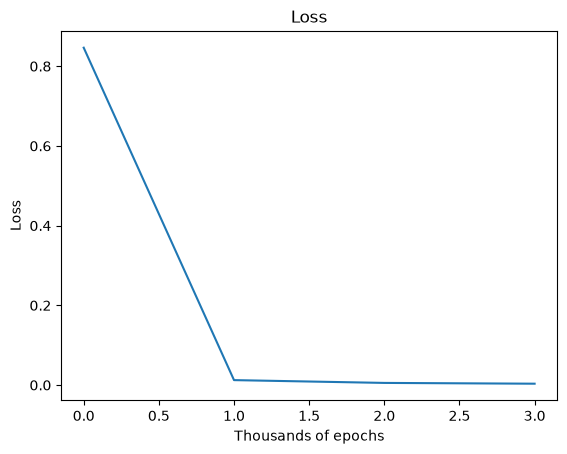

In [27]:
# Plot error during different epochs
plt.plot(loss_history)
plt.title('Loss')
plt.xlabel('Thousands of epochs')
plt.ylabel('Loss')
plt.show()

In [28]:
loss_history

[0.8464378714561462,
 0.012384962290525436,
 0.005367716308683157,
 0.003407851792871952]

Note that this notebook uses binary cross-entropy as loss unlike the tensorflow one. The reason is that the derivatives of the sigmoid and the logs in the loss function cancel out nicely, which allows for efficient training. 

# Deriving the BCE + Sigmoid Gradient

We have the output neuron with:

$$
z = \text{input to the sigmoid}
$$

and

$$
\hat y = \sigma(z)
$$

where the sigmoid is:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Our binary cross-entropy loss for one observation is:

$$
L=-\left[y\log(\hat y)+(1-y)\log(1-\hat y)\right]
$$

We want to find:

$$
\frac{\partial L}{\partial z}
$$

---

## 1. Start with the loss

$$
L=-\left[y\log(\hat y)+(1-y)\log(1-\hat y)\right]
$$

Since \(\hat y\) depends on \(z\), we need the **chain rule**:

$$
\frac{\partial L}{\partial z}
=
\frac{\partial L}{\partial \hat y}
\frac{\partial \hat y}{\partial z}
$$

So we calculate these two derivatives separately.

---

## 2. Derivative of the BCE with respect to $\hat y$

Start with:

$$
L=-y\log(\hat y)-(1-y)\log(1-\hat y)
$$

We use:

$$
\frac{d}{dx}\log(x)=\frac{1}{x}
$$

For the first term:

$$
\frac{\partial}{\partial\hat y}
[-y\log(\hat y)]
=
-\frac{y}{\hat y}
$$

For the second term, we need the chain rule:

$$
\frac{\partial}{\partial\hat y}
[-(1-y)\log(1-\hat y)]
$$

The derivative of $\log(1-\hat y)$ is:

$$
\frac{1}{1-\hat y}(-1)
$$

Therefore:

$$
\frac{\partial}{\partial\hat y}
[-(1-y)\log(1-\hat y)]
=
\frac{1-y}{1-\hat y}
$$

Putting the two terms together:

$$
\frac{\partial L}{\partial\hat y}
=
-\frac{y}{\hat y}
+
\frac{1-y}{1-\hat y}
$$

---

## 3. Simplify the BCE derivative

Put everything over the common denominator:

$$
\frac{\partial L}{\partial\hat y}
=
\frac{-y(1-\hat y)+(1-y)\hat y}
{\hat y(1-\hat y)}
$$

Expand the numerator:

$$
-y+y\hat y+\hat y-y\hat y
$$

The \(y\hat y\) terms cancel:

$$
-y+\hat y
$$

So:

$$
\boxed{
\frac{\partial L}{\partial\hat y}
=
\frac{\hat y-y}
{\hat y(1-\hat y)}
}
$$

---

## 4. Derivative of the sigmoid

We have:

$$
\hat y=\sigma(z)
=
\frac{1}{1+e^{-z}}
$$

Its derivative is:

$$
\boxed{
\frac{\partial\hat y}{\partial z}
=
\hat y(1-\hat y)
}
$$

This is the important part.

---

## 5. Apply the chain rule

We had:

$$
\frac{\partial L}{\partial z}
=
\frac{\partial L}{\partial\hat y}
\frac{\partial\hat y}{\partial z}
$$

Substitute the two derivatives:

$$
\frac{\partial L}{\partial z}
=
\frac{\hat y-y}
{\hat y(1-\hat y)}
\cdot
\hat y(1-\hat y)
$$

And now the magic happens:

$$
\hat y(1-\hat y)
$$

appears in both the numerator and denominator, so it cancels:

$$
\boxed{
\frac{\partial L}{\partial z}
=
\hat y-y
}
$$





Compare this with the output error from the tensorflow notebook, which is numerically really low when $\hat y$ appraches 0 or 1, even when it approaches the wrong answer! This produces a small gradient even with a large error and thus delays the network's learning.

$$
\boxed{
\delta_3
=
\frac{\partial L}{\partial z_3}
=
(\hat y-y)\hat y(1-\hat y)
}
$$